# Evaluate Product Hair Segmentation Model

Standard DL evaluation for the heavier segmentation checkpoint.
This notebook keeps the essentials:
- training-history plots
- validation scores
- confusion-style pixel matrix
- threshold sweep plot
- qualitative prediction examples


In [9]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from systems.static_auto_tryon.auto_app.ml.datasets import HairSegmentationDataset, read_jsonl_manifest
from systems.static_auto_tryon.auto_app.ml.hair_segmentation_model import build_segmentation_model
from systems.static_auto_tryon.auto_app.ml.metrics import dice_coefficient_from_logits, iou_from_logits, pixel_accuracy_from_logits
from systems.static_auto_tryon.auto_app.ml.transforms import ResizeImageAndMask

PROJECT_ROOT


WindowsPath('.')

In [10]:
VAL_MANIFEST = PROJECT_ROOT / 'backend' / 'data' / 'datasets' / 'hair_segmentation' / 'val.jsonl'
CHECKPOINT_PATH = PROJECT_ROOT / 'backend' / 'models' / 'hair_segmentation' / 'v2_unet_product.pt'

IMAGE_SIZE = (256, 256)
BATCH_SIZE = 12
THRESHOLD = 0.5
THRESHOLD_SWEEP = [0.30, 0.40, 0.50, 0.60, 0.70]
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pd.Series(
    {
        'val_manifest_exists': VAL_MANIFEST.exists(),
        'checkpoint_exists': CHECKPOINT_PATH.exists(),
        'device': DEVICE,
        'threshold': THRESHOLD,
    }
)


val_manifest_exists    True
checkpoint_exists      True
device                 cuda
threshold               0.5
dtype: object

In [11]:
val_records = read_jsonl_manifest(VAL_MANIFEST)
val_dataset = HairSegmentationDataset(val_records, transform=ResizeImageAndMask(IMAGE_SIZE))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

payload = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
history = pd.DataFrame(payload.get('history', []))
model = build_segmentation_model(model_name='unet', base_channels=32)
model.load_state_dict(payload['model_state_dict'])
model.to(DEVICE)
model.eval()

pd.Series(
    {
        'val_records': len(val_records),
        'history_rows': len(history),
        'best_epoch': int(history.loc[history['dice'].idxmax(), 'epoch']) if not history.empty else None,
        'best_dice': float(history['dice'].max()) if not history.empty else None,
    }
)


val_records     4395.000000
history_rows      12.000000
best_epoch        12.000000
best_dice          0.942676
dtype: float64

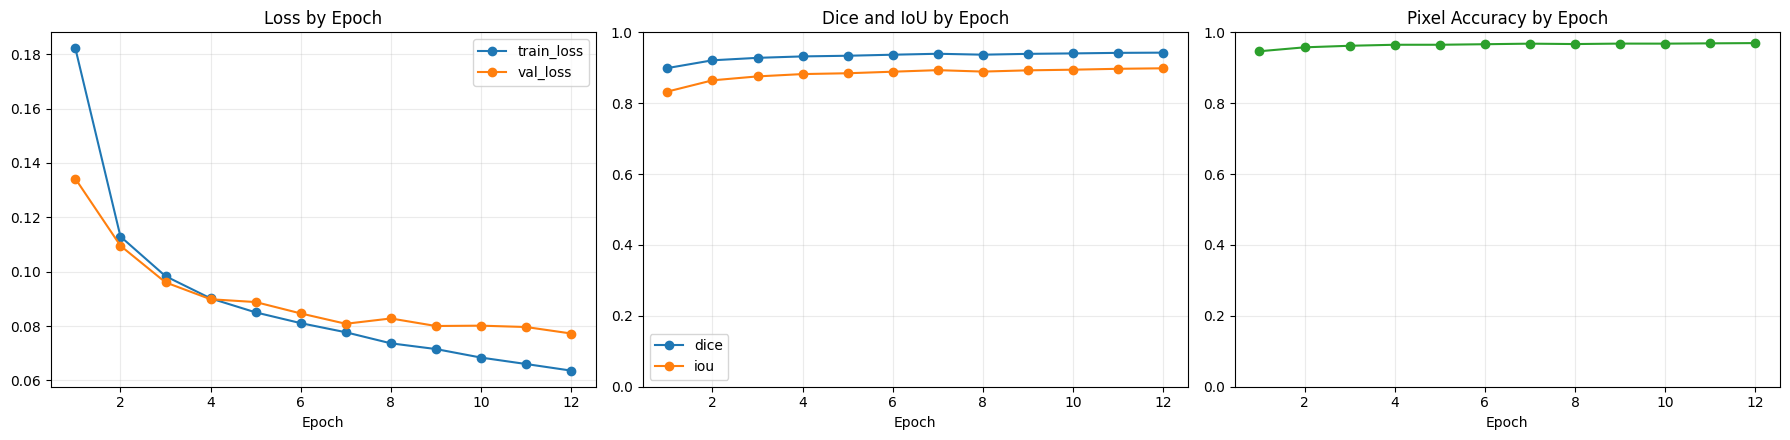

,epoch,train_loss,val_loss,dice,iou,pixel_accuracy,epoch_time,best_epoch_so_far,best_dice_so_far
7,8,0.073629,0.082775,0.936950,0.889243,0.966914,48:18,7,0.9395
8,9,0.071521,0.080003,0.939264,0.892754,0.968233,24:37,7,0.9395
9,10,0.068385,0.080129,0.940538,0.894586,0.968102,24:45,10,0.9405
10,11,0.066017,0.079628,0.942079,0.897113,0.968926,24:46,11,0.9421
11,12,0.063591,0.077241,0.942676,0.898520,0.969650,24:46,12,0.9427


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='train_loss')
axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='val_loss')
axes[0].set_title('Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history['epoch'], history['dice'], marker='o', label='dice')
axes[1].plot(history['epoch'], history['iou'], marker='o', label='iou')
axes[1].set_title('Dice and IoU by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(history['epoch'], history['pixel_accuracy'], marker='o', color='tab:green')
axes[2].set_title('Pixel Accuracy by Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.0, 1.0)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

history.tail()


In [13]:
def confusion_counts_from_logits(logits: torch.Tensor, targets: torch.Tensor, threshold: float) -> dict[str, int]:
    probs = torch.sigmoid(logits)
    preds = probs >= threshold
    truth = targets >= 0.5
    return {
        'tp': int((preds & truth).sum().item()),
        'fp': int((preds & ~truth).sum().item()),
        'tn': int((~preds & ~truth).sum().item()),
        'fn': int((~preds & truth).sum().item()),
    }


def precision_recall_f1(counts: dict[str, int], eps: float = 1e-8) -> dict[str, float]:
    tp, fp, tn, fn = counts['tp'], counts['fp'], counts['tn'], counts['fn']
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1 = (2 * precision * recall) / (precision + recall + eps)
    return {
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
    }


def evaluate_model(model: nn.Module, loader: DataLoader, threshold: float = 0.5):
    criterion = nn.BCEWithLogitsLoss()
    running_loss = 0.0
    metric_sums = {'dice': 0.0, 'iou': 0.0, 'pixel_accuracy': 0.0}
    counts = {'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0}
    sample_rows = []

    model.eval()
    with torch.inference_mode():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            masks = batch['mask'].to(DEVICE)
            logits = model(images)

            running_loss += float(criterion(logits, masks).item())
            metric_sums['dice'] += dice_coefficient_from_logits(logits, masks, threshold=threshold)
            metric_sums['iou'] += iou_from_logits(logits, masks, threshold=threshold)
            metric_sums['pixel_accuracy'] += pixel_accuracy_from_logits(logits, masks, threshold=threshold)

            batch_counts = confusion_counts_from_logits(logits, masks, threshold)
            for key in counts:
                counts[key] += batch_counts[key]

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()
            for idx, source_id in enumerate(batch['source_id']):
                sample_rows.append(
                    {
                        'source_id': source_id,
                        'dice': dice_coefficient_from_logits(logits[idx:idx+1], masks[idx:idx+1], threshold=threshold),
                        'iou': iou_from_logits(logits[idx:idx+1], masks[idx:idx+1], threshold=threshold),
                        'pixel_accuracy': pixel_accuracy_from_logits(logits[idx:idx+1], masks[idx:idx+1], threshold=threshold),
                        'gt_coverage': float(masks[idx, 0].float().mean().item()),
                        'pred_coverage': float(preds[idx, 0].float().mean().item()),
                    }
                )

    batch_count = max(len(loader), 1)
    summary = {
        'val_loss': running_loss / batch_count,
        'dice': metric_sums['dice'] / batch_count,
        'iou': metric_sums['iou'] / batch_count,
        'pixel_accuracy': metric_sums['pixel_accuracy'] / batch_count,
        **counts,
        **precision_recall_f1(counts),
    }
    return summary, pd.DataFrame(sample_rows)


def evaluate_thresholds(model: nn.Module, loader: DataLoader, thresholds: list[float]) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        summary, _ = evaluate_model(model, loader, threshold=threshold)
        rows.append({'threshold': threshold, **summary})
    return pd.DataFrame(rows)


In [14]:
summary, per_sample = evaluate_model(model, val_loader, threshold=THRESHOLD)
pd.Series(summary)


val_loss          7.724069e-02
dice              9.427487e-01
iou               8.986410e-01
pixel_accuracy    9.696736e-01
tp                9.100439e+07
fp                4.519612e+06
tn                1.882846e+08
fn                4.222147e+06
precision         9.526861e-01
recall            9.556621e-01
specificity       9.765585e-01
f1                9.541718e-01
dtype: float64

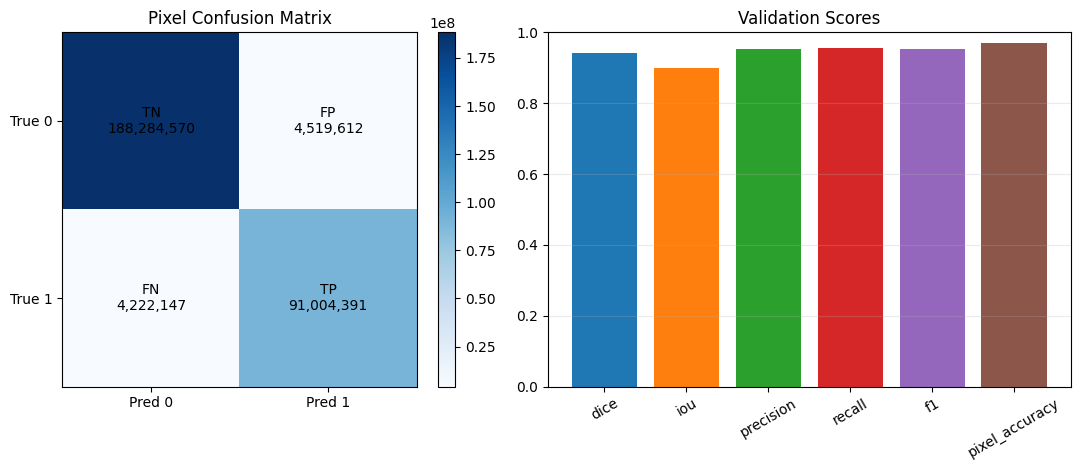

In [16]:
confusion_matrix = np.array([[summary['tn'], summary['fp']], [summary['fn'], summary['tp']]], dtype=np.float64)
labels = np.array([['TN', 'FP'], ['FN', 'TP']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

im = axes[0].imshow(confusion_matrix, cmap='Blues')
axes[0].set_title('Pixel Confusion Matrix')
axes[0].set_xticks([0, 1], labels=['Pred 0', 'Pred 1'])
axes[0].set_yticks([0, 1], labels=['True 0', 'True 1'])
for row in range(2):
    for col in range(2):
        axes[0].text(col, row, f"{labels[row, col]}\n{int(confusion_matrix[row, col]):,}", ha='center', va='center')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

bar_metrics = pd.Series(
    {
        'dice': summary['dice'],
        'iou': summary['iou'],
        'precision': summary['precision'],
        'recall': summary['recall'],
        'f1': summary['f1'],
        'pixel_accuracy': summary['pixel_accuracy'],
    }
)
axes[1].bar(bar_metrics.index, bar_metrics.values, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Validation Scores')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


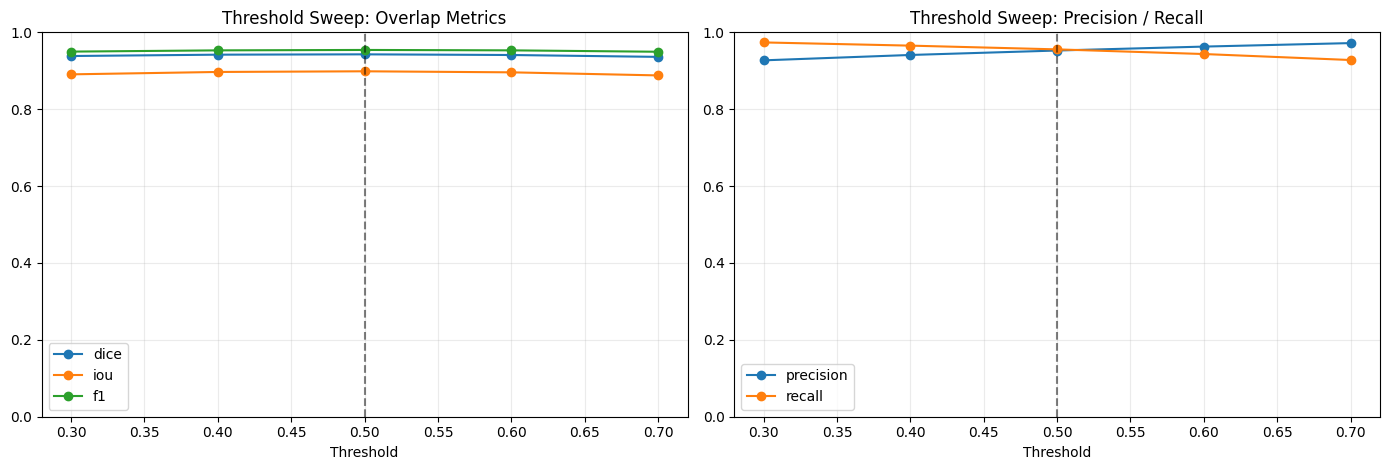

,threshold,dice,iou,precision,recall,f1
0,0.3,0.938382,0.890693,0.927119,0.973744,0.949859
1,0.4,0.941879,0.896912,0.941107,0.965404,0.953100
2,0.5,0.942749,0.898641,0.952686,0.955662,0.954172
3,0.6,0.941012,0.895937,0.962902,0.943552,0.953129
4,0.7,0.936151,0.887942,0.972009,0.927973,0.949481


In [17]:
threshold_results = evaluate_thresholds(model, val_loader, THRESHOLD_SWEEP)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(threshold_results['threshold'], threshold_results['dice'], marker='o', label='dice')
axes[0].plot(threshold_results['threshold'], threshold_results['iou'], marker='o', label='iou')
axes[0].plot(threshold_results['threshold'], threshold_results['f1'], marker='o', label='f1')
axes[0].axvline(THRESHOLD, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Threshold Sweep: Overlap Metrics')
axes[0].set_xlabel('Threshold')
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(threshold_results['threshold'], threshold_results['precision'], marker='o', label='precision')
axes[1].plot(threshold_results['threshold'], threshold_results['recall'], marker='o', label='recall')
axes[1].axvline(THRESHOLD, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Threshold Sweep: Precision / Recall')
axes[1].set_xlabel('Threshold')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

threshold_results[['threshold', 'dice', 'iou', 'precision', 'recall', 'f1']]


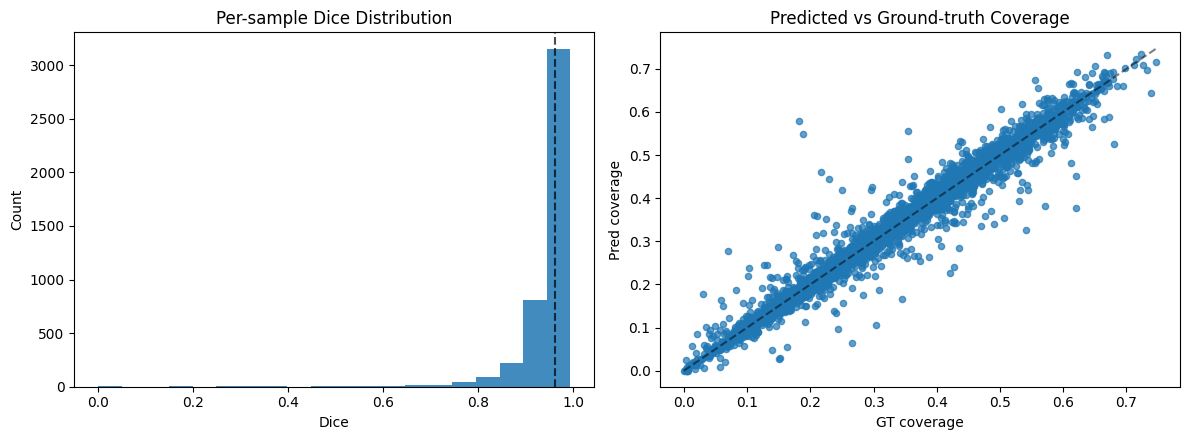

,source_id,dice,iou,pixel_accuracy,gt_coverage,pred_coverage
1852,10157,2.114165e-09,2.114165e-09,0.992783,0.007126,0.000092
702,09927,3.389830e-09,3.389830e-09,0.995499,0.004501,0.000000
3770,03824,3.472222e-09,3.472222e-09,0.995605,0.004395,0.000000
357,07102,5.319149e-09,5.319149e-09,0.997131,0.002823,0.000046
4019,01941,4.999999e-08,4.999999e-08,0.999695,0.000259,0.000046
1809,16173,4.348145e-02,2.222389e-02,0.801285,0.029449,0.178299
828,28519,1.119483e-01,5.929304e-02,0.987411,0.005524,0.008652
2736,00465,1.660730e-01,9.055596e-02,0.942841,0.012115,0.056427
219,29175,1.771460e-01,9.718056e-02,0.977036,0.003113,0.024796
335,05125,1.839298e-01,1.012790e-01,0.947464,0.056549,0.007828


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(per_sample['dice'], bins=20, color='tab:blue', alpha=0.85)
axes[0].axvline(per_sample['dice'].median(), color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Per-sample Dice Distribution')
axes[0].set_xlabel('Dice')
axes[0].set_ylabel('Count')

axes[1].scatter(per_sample['gt_coverage'], per_sample['pred_coverage'], alpha=0.7, s=20)
max_cov = float(max(per_sample['gt_coverage'].max(), per_sample['pred_coverage'].max()))
axes[1].plot([0, max_cov], [0, max_cov], linestyle='--', color='black', alpha=0.5)
axes[1].set_title('Predicted vs Ground-truth Coverage')
axes[1].set_xlabel('GT coverage')
axes[1].set_ylabel('Pred coverage')

plt.tight_layout()
plt.show()

per_sample.sort_values('dice').head(10)


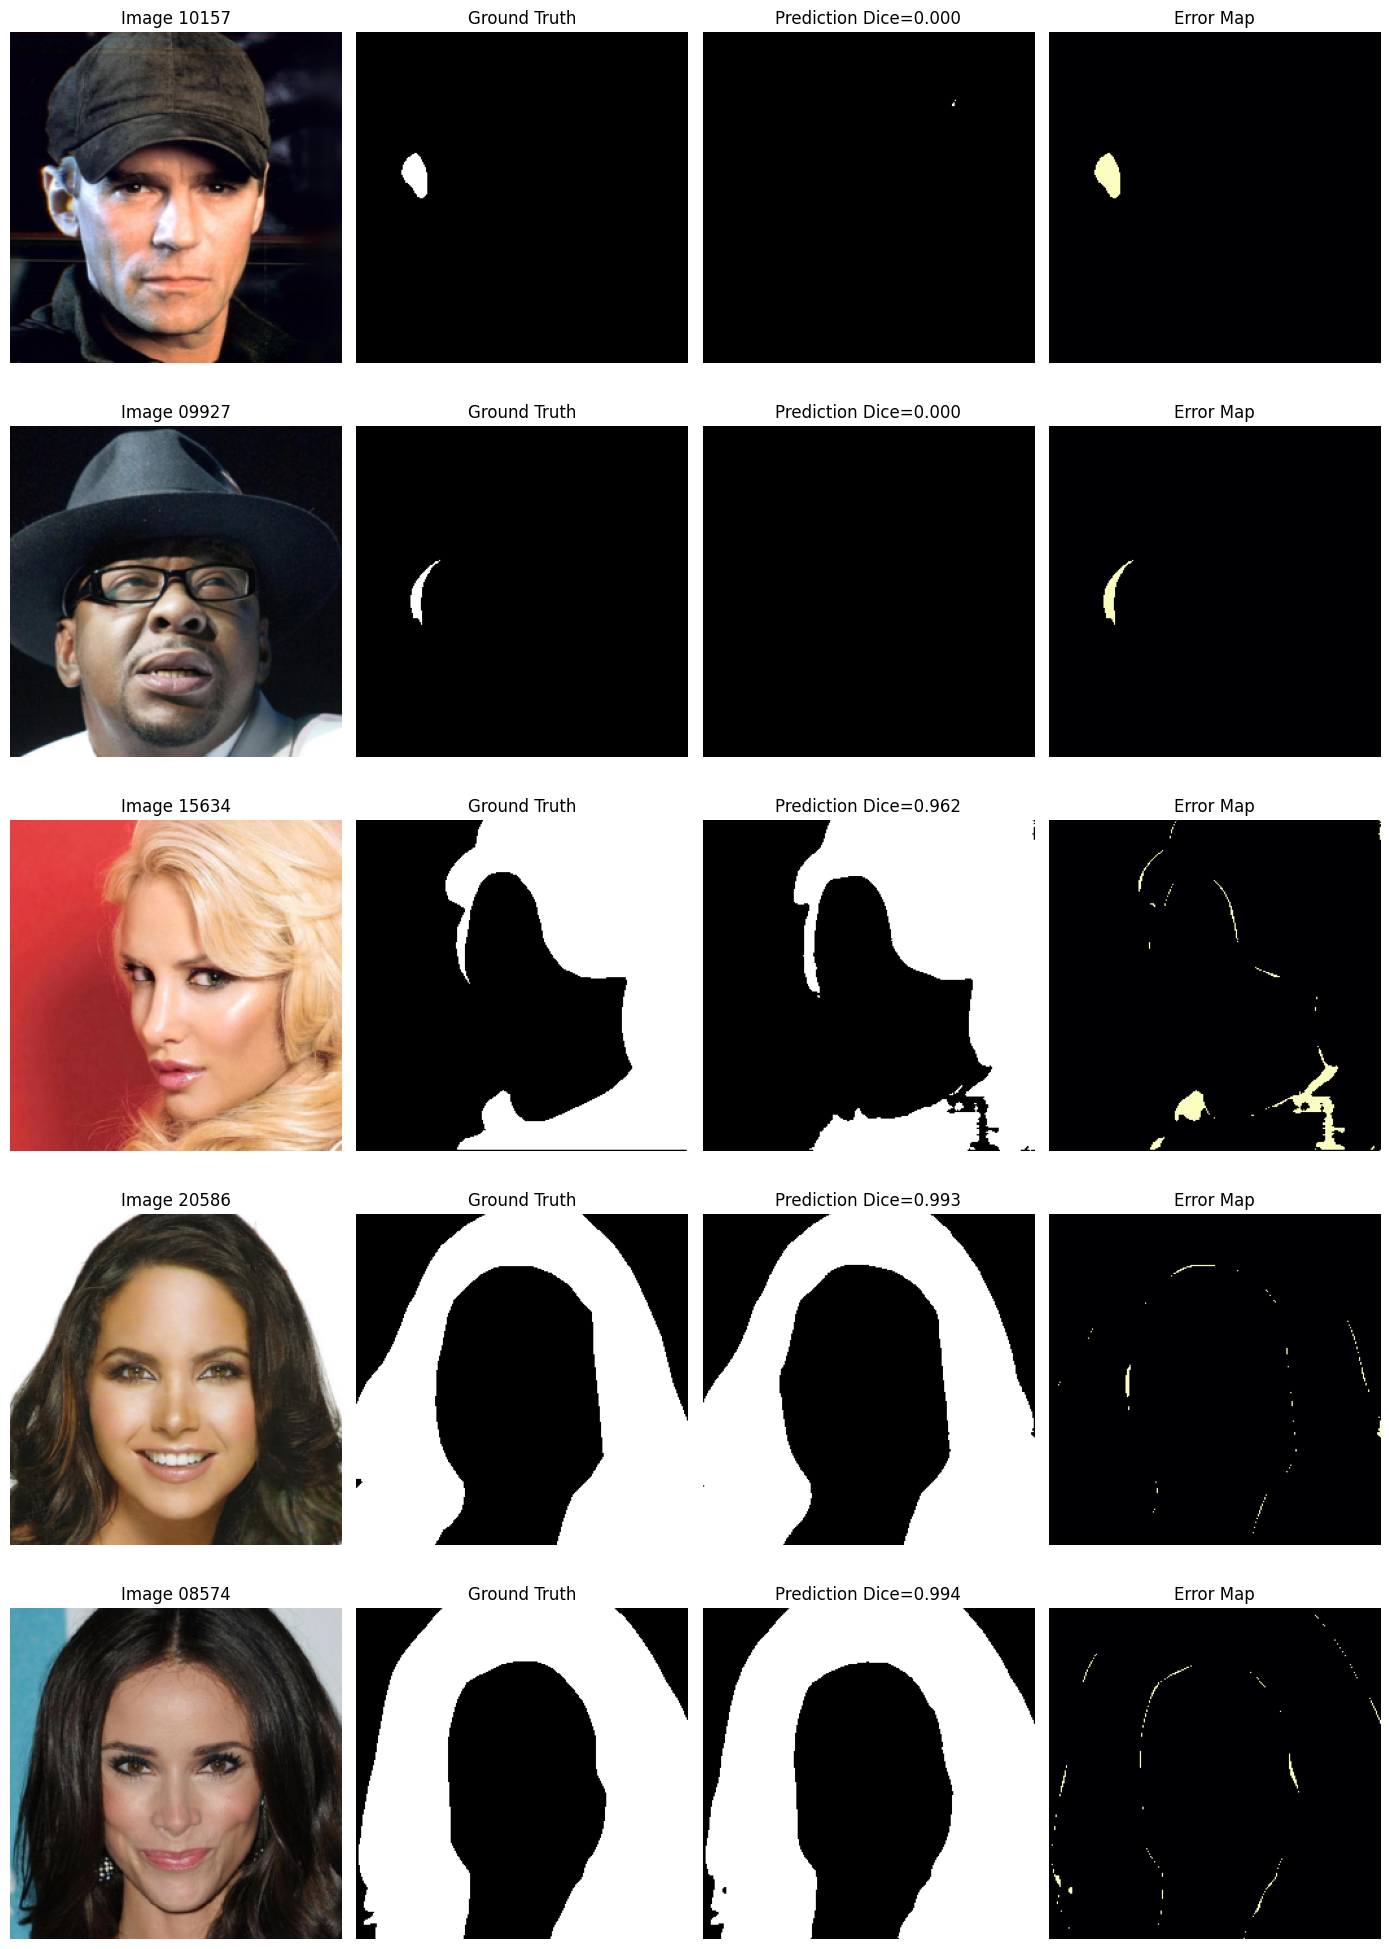

,source_id,dice,iou,pixel_accuracy,gt_coverage,pred_coverage
0,10157,2.114165e-09,2.114165e-09,0.992783,0.007126,0.000092
1,09927,3.389830e-09,3.389830e-09,0.995499,0.004501,0.000000
2,15634,9.617964e-01,9.264045e-01,0.968536,0.418533,0.405045
3,20586,9.931200e-01,9.863340e-01,0.993347,0.483459,0.483521
4,08574,9.938434e-01,9.877622e-01,0.992905,0.577728,0.574753


In [21]:
record_lookup = {str(record['source_id']): record for record in val_records}

with torch.inference_mode():
    prediction_cache = {}
    for record in val_records:
        image = Image.open(PROJECT_ROOT / str(record['image_path'])).convert('RGB').resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
        image_np = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_np.transpose(2, 0, 1)).unsqueeze(0).to(DEVICE)
        logits = model(image_tensor)
        prediction_cache[str(record['source_id'])] = (torch.sigmoid(logits)[0, 0].cpu().numpy() >= THRESHOLD).astype(np.uint8)

ranked = per_sample.sort_values('dice').reset_index(drop=True)
selected_rows = pd.concat([
    ranked.head(2),
    ranked.iloc[[len(ranked) // 2]],
    ranked.tail(2),
], ignore_index=True)

fig, axes = plt.subplots(len(selected_rows), 4, figsize=(14, 4 * len(selected_rows)))
if len(selected_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, sample in selected_rows.iterrows():
    source_id = str(sample['source_id'])
    record = record_lookup[source_id]
    image = Image.open(PROJECT_ROOT / str(record['image_path'])).convert('RGB').resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
    gt_mask = Image.open(PROJECT_ROOT / str(record['mask_path'])).convert('L').resize(IMAGE_SIZE, Image.Resampling.NEAREST)
    image_np = np.asarray(image)
    gt_mask_np = (np.asarray(gt_mask) > 0).astype(np.uint8)
    pred_mask_np = prediction_cache[source_id]
    error_map = np.abs(pred_mask_np - gt_mask_np)

    axes[row_index, 0].imshow(image_np)
    axes[row_index, 0].set_title(f"Image {source_id}")
    axes[row_index, 1].imshow(gt_mask_np, cmap='gray')
    axes[row_index, 1].set_title('Ground Truth')
    axes[row_index, 2].imshow(pred_mask_np, cmap='gray')
    axes[row_index, 2].set_title(f"Prediction Dice={sample['dice']:.3f}")
    axes[row_index, 3].imshow(error_map, cmap='magma')
    axes[row_index, 3].set_title('Error Map')

    for col in range(4):
        axes[row_index, col].axis('off')

plt.tight_layout()
plt.show()

selected_rows[['source_id', 'dice', 'iou', 'pixel_accuracy', 'gt_coverage', 'pred_coverage']]
